##### Project 2 — Triage Latency Prediction
##### Notebook 06: Robustness & Drift Analysis

##### Objective

- Determine whether the observed regression failure is primarily caused by:

1. Model limitations
2. Temporal/process drift
3. Population or feature drift
4. Rare long-delay regime instability
5. Company/product composition changes

##### Core principle

The test set is frozen.

Train and validation are used for development diagnosis.
The test set is inspected only descriptively and will not influence model selection.

##### Key Question

- Is the one-stage regression model failing because it is weak,
or because the underlying operational process contains distinct regimes
that require a different modeling architecture?

##### Why Robustness & Drift Analysis?

Notebook 05 showed a strong failure pattern:

- Near-immediate complaints are overpredicted.
- Long-delay complaints are severely underpredicted.
- >7 day detection recall was only about 10.6%.
- Predictions are strongly compressed toward the center.
- Validation contains substantially more long delays than the later test period.

Therefore, before moving directly to a two-stage model, we need to determine:

> Does the target/process itself change across time and population?

If the process is unstable, simply using a more powerful model may not solve the problem.

- A model can fail because:- Model is too weak

- or because:-  Reality changed

- or because:-  Reality contains multiple operational regimes.

- This notebook investigates those possibilities.

In [ ]:
## Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
## Paths
PROJECT_ROOT = Path.cwd().parent.parent

RAW_PATH = PROJECT_ROOT / "Data" /"raw"/ "complaints-cfpb-raw.csv"

print("Project root:", PROJECT_ROOT)
print("Raw data path:", RAW_PATH)

Project root: d:\GURU_PROJECTS\ML-FINTECH&BANK
Raw data path: d:\GURU_PROJECTS\ML-FINTECH&BANK\Data\raw\complaints-cfpb-raw.csv


In [ ]:
df = pd.read_csv(RAW_PATH)

print("Shape:", df.shape)
display(df.head())

## No cleaning, filtering, transformation, or row deletion is performed here.

## The purpose is to recreate the same target and inspect distributions across the frozen temporal partitions.

Shape: (81946, 16)


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Submitted via,Date sent to company,Company response to consumer,Timely response?,Complaint ID
0,2026-04-30T00:26:44.000Z,Debt collection,Auto debt,Attempts to collect debt not owed,Debt is not yours,"The collection is supposed to be from "" The Ge...",NaN,Credit Bureau Services Association,GA,30297,"Older American, Servicemember",Web,2026-06-15T16:24:21.000Z,Untimely response,No,21732493
1,2026-04-29T12:51:13.000Z,Debt collection,Credit card debt,Attempts to collect debt not owed,Debt is not yours,I received as phone call from Zenco Collection...,NaN,"ZENCO COLLECTION, LLC",IN,47421,NaN,Web,2026-06-15T16:40:23.000Z,Untimely response,No,21704246
2,2026-04-30T00:19:46.000Z,Debt collection,I do not know,Attempts to collect debt not owed,Debt was result of identity theft,On XX/XX/year> I received a notice from XXXX X...,NaN,"Revco Management, LLC",NV,89074,Servicemember,Web,2026-06-15T18:23:14.000Z,Closed with non-monetary relief,Yes,21731421
3,2026-04-29T20:05:16.000Z,Debt collection,Credit card debt,Communication tactics,Frequent or repeated calls,MRS BRO sent text messages with my name and de...,Company believes it acted appropriately as aut...,"MRS BPO, LLC",CA,93257,NaN,Web,2026-06-15T19:50:13.000Z,Closed with non-monetary relief,Yes,21722031
4,2026-04-29T10:01:28.000Z,Credit card,General-purpose credit card or charge card,Trouble using your card,Can't use card to make purchases,"On XX/XX/year>, Chime financial greyed out my ...",NaN,Chime Financial Inc,NV,89106,NaN,Web,2026-06-15T16:06:00.000Z,Closed with explanation,Yes,21701671


In [3]:
## Parse Dates & Constructs Target
df["Date received"] = pd.to_datetime(df["Date received"], utc=True)
df["Date sent to company"] = pd.to_datetime(df["Date sent to company"], utc=True)

df["triage_delay_days"] = (
    df["Date sent to company"] - df["Date received"]
).dt.total_seconds() / 86400

print("Rows:", len(df))
print("Target missing:", df["triage_delay_days"].isna().sum())
print("Target negative:", (df["triage_delay_days"] < 0).sum())

Rows: 81946
Target missing: 0
Target negative: 0


##### Recreate the Frozen Temporal Split

Notebook 03 established the development split using chronological ordering:

- Train ≈ 70%
- Validation ≈ 15%
- Test ≈ 15%

The same boundary logic is reproduced here. No rows are shuffled.

In [ ]:
df_sorted = df.sort_values("Date received").reset_index(drop=True)

n = len(df_sorted)

train_end = int(n * 0.70)
val_end = train_end + int(n * 0.15)

train = df_sorted.iloc[:train_end].copy()
val = df_sorted.iloc[train_end:val_end].copy()
test = df_sorted.iloc[val_end:].copy()

print("Train:", train.shape)
print("Validation:", val.shape)
print("Test:", test.shape)

Train: (57362, 17)
Validation: (12291, 17)
Test: (12293, 17)


In [5]:
## Verify Boundaries
split_summary = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "rows": [len(train), len(val), len(test)],
    "start": [
        train["Date received"].min(),
        val["Date received"].min(),
        test["Date received"].min()
    ],
    "end": [
        train["Date received"].max(),
        val["Date received"].max(),
        test["Date received"].max()
    ]
})

display(split_summary)

,split,rows,start,end
0,train,57362,2026-03-01 00:41:56+00:00,2026-05-27 18:08:25+00:00
1,validation,12291,2026-05-27 18:09:09+00:00,2026-06-17 14:32:33+00:00
2,test,12293,2026-06-17 14:33:53+00:00,2026-08-11 14:27:33+00:00


In [ ]:
## Split Integrity Check
assert train["Date received"].max() <= val["Date received"].min()
assert val["Date received"].max() <= test["Date received"].min()

print("Temporal ordering: PASS")

Temporal ordering: PASS


##### Part 1 — Target Distribution Drift

The first question:

> Did operational latency itself change over time?

This is more important than comparing only the mean.

Because the target is extremely right-skewed, we inspect:

- Mean
- Median
- P90
- P95
- P99
- Maximum
- Long-delay prevalence

- A large mean change can occur simply because a few extreme delays changed.
Therefore, quantiles and threshold prevalence are essential.

In [7]:
## Target Summary Function
def target_summary(data, name):
    y = data["triage_delay_days"]

    return {
        "split": name,
        "n": len(y),
        "mean": y.mean(),
        "median": y.median(),
        "p90": y.quantile(0.90),
        "p95": y.quantile(0.95),
        "p99": y.quantile(0.99),
        "max": y.max(),
        ">1d_%": (y > 1).mean() * 100,
        ">3d_%": (y > 3).mean() * 100,
        ">7d_%": (y > 7).mean() * 100,
        ">14d_%": (y > 14).mean() * 100,
        ">30d_%": (y > 30).mean() * 100,
    }

target_drift = pd.DataFrame([
    target_summary(train, "Train"),
    target_summary(val, "Validation"),
    target_summary(test, "Test")
])

display(target_drift.round(4))

,split,n,mean,median,p90,p95,p99,max,>1d_%,>3d_%,>7d_%,>14d_%,>30d_%
0,Train,57362,2.2181,0.0099,0.0453,18.8653,46.7290,146.7916,7.4422,7.2679,6.8582,5.7808,3.7011
1,Validation,12291,1.0983,0.0099,0.0380,7.4209,27.9919,91.8460,5.7929,5.6871,5.1664,2.8964,0.8950
2,Test,12293,0.1819,0.0101,0.0332,0.0551,6.8140,54.9815,2.0255,1.7652,0.9192,0.1058,0.0407


##### Target Distribution by Split

Because the raw target contains a very long right tail, a logarithmic x-axis is useful.

This is visualization only.

We are not transforming the target for modeling here.

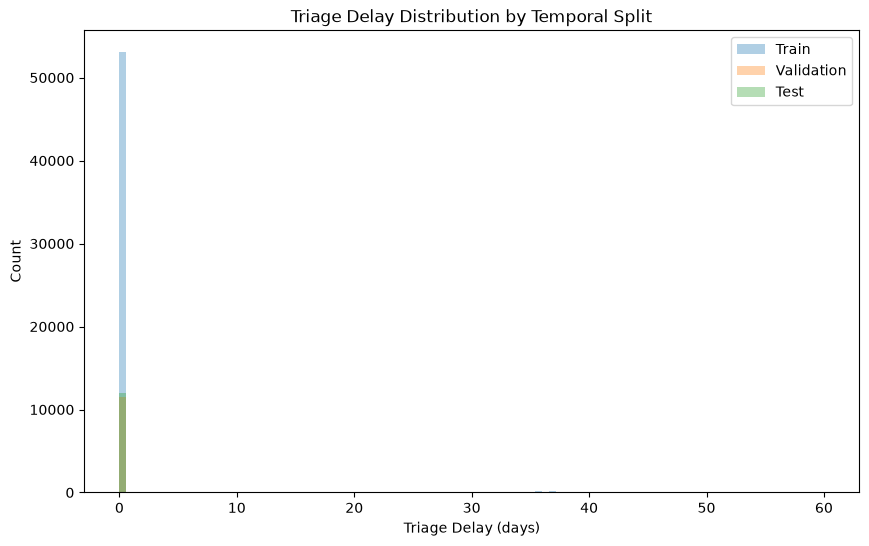

In [8]:
plt.figure(figsize=(10, 6))

for data, label in [
    (train, "Train"),
    (val, "Validation"),
    (test, "Test")
]:
    y = data["triage_delay_days"]
    plt.hist(
        y,
        bins=100,
        alpha=0.35,
        label=label,
        range=(0, 60)
    )

plt.xlabel("Triage Delay (days)")
plt.ylabel("Count")
plt.title("Triage Delay Distribution by Temporal Split")
plt.legend()
plt.show()

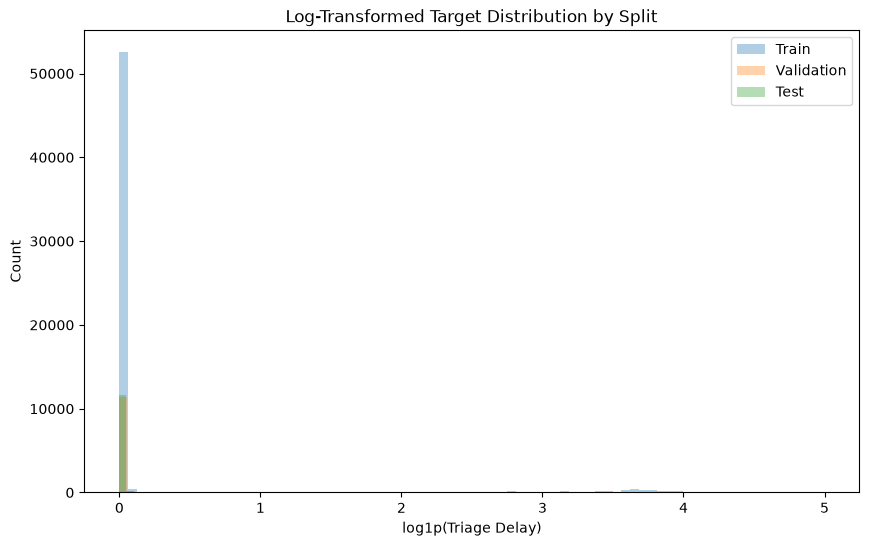

In [9]:
## Log Visualization
plt.figure(figsize=(10, 6))

for data, label in [
    (train, "Train"),
    (val, "Validation"),
    (test, "Test")
]:
    y = np.log1p(data["triage_delay_days"])
    plt.hist(y, bins=80, alpha=0.35, label=label)

plt.xlabel("log1p(Triage Delay)")
plt.ylabel("Count")
plt.title("Log-Transformed Target Distribution by Split")
plt.legend()
plt.show()

##### Threshold Prevalence
##### Long-Delay Regime Stability

The potential two-stage architecture depends on the existence of a meaningful delayed regime.

Therefore we inspect several candidate thresholds:

- >1 day
- >3 days
- >7 days
- >14 days
- >30 days

We are NOT choosing the final threshold yet.

The purpose is to understand:

> Which thresholds remain sufficiently populated and reasonably stable across time?

In [10]:
thresholds = [1, 3, 7, 14, 30]

rows = []

for threshold in thresholds:
    rows.append({
        "threshold_days": threshold,
        "train_n": (train["triage_delay_days"] > threshold).sum(),
        "train_%": (train["triage_delay_days"] > threshold).mean() * 100,
        "val_n": (val["triage_delay_days"] > threshold).sum(),
        "val_%": (val["triage_delay_days"] > threshold).mean() * 100,
        "test_n": (test["triage_delay_days"] > threshold).sum(),
        "test_%": (test["triage_delay_days"] > threshold).mean() * 100,
    })

threshold_drift = pd.DataFrame(rows)

display(threshold_drift.round(3))

,threshold_days,train_n,train_%,val_n,val_%,test_n,test_%
0,1,4269,7.442,712,5.793,249,2.026
1,3,4169,7.268,699,5.687,217,1.765
2,7,3934,6.858,635,5.166,113,0.919
3,14,3316,5.781,356,2.896,13,0.106
4,30,2123,3.701,110,0.895,5,0.041


##### Interpretation Checkpoint — Target Drift

Ask:

1. Is the median stable?
2. Does the mean change substantially?
3. Do P95/P99 change?
4. Does the >7 day regime remain stable?
5. Does the >30 day regime remain learnable?
6. Is the test period substantially easier than train/validation?

Important:

- If the test period contains almost no extreme delays, excellent test MAE
would NOT prove that the model learned the long-delay regime.

- It may simply mean the test period contains fewer difficult cases.

##### Part 2 — Product Distribution Drift

Product is potentially useful for prediction, but its operational availability
at intake must still be verified before being treated as a production feature.

Here we are not deciding whether Product is allowed.

We are only asking:

> Does the complaint population by Product change across temporal splits?

Large changes can cause model performance changes even when the model itself is unchanged.

In [11]:
def categorical_distribution(data, column, name):
    dist = data[column].value_counts(normalize=True) * 100
    return dist.rename(name)

product_dist = pd.concat([
    categorical_distribution(train, "Product", "Train"),
    categorical_distribution(val, "Product", "Validation"),
    categorical_distribution(test, "Product", "Test")
], axis=1).fillna(0)

product_dist["Max absolute shift"] = (
    product_dist[["Validation", "Test"]]
    .sub(product_dist["Train"], axis=0)
    .abs()
    .max(axis=1)
)

display(
    product_dist.sort_values("Train", ascending=False).round(3)
)

,Train,Validation,Test,Max absolute shift
Product,,,,
Debt collection,34.258,31.950,27.772,6.486
Checking or savings account,17.027,18.599,21.313,4.286
Credit card,16.581,16.947,18.108,1.527
"Money transfer, virtual currency, or money service",8.256,7.420,7.297,0.960
Mortgage,6.293,6.785,7.256,0.963
Vehicle loan or lease,4.921,4.621,4.897,0.300
Credit reporting or other personal consumer reports,3.858,4.792,4.629,0.934
"Payday loan, title loan, personal loan, or advance loan",3.471,3.694,3.685,0.223
Student loan,3.380,3.295,2.790,0.590


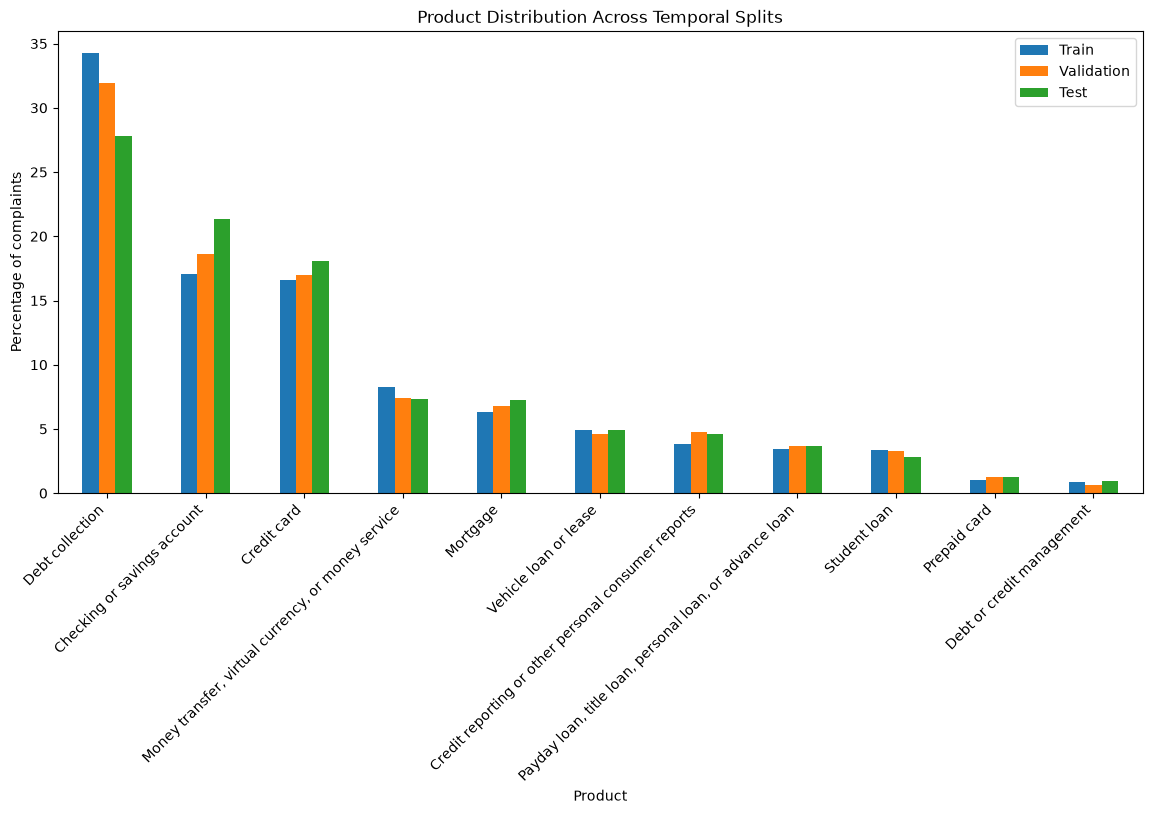

In [12]:
## Product Drift Visualization
product_dist[["Train", "Validation", "Test"]].plot(
    kind="bar",
    figsize=(14, 6)
)

plt.ylabel("Percentage of complaints")
plt.title("Product Distribution Across Temporal Splits")
plt.xticks(rotation=45, ha="right")
plt.show()

##### Part 3 — Company Coverage & Generalization Risk

Notebook 05 showed substantial company-level error heterogeneity.

Company is also a high-cardinality feature.

This creates a critical robustness question:

> Does the model encounter the same companies during training and validation?

If validation contains many unseen companies, performance may fall because
the model cannot memorize company-specific operational patterns.

We therefore inspect:

- Number of companies
- New companies appearing later
- Percentage of rows belonging to unseen companies
- Company concentration

In [13]:
def company_coverage(train_data, other_data, name):
    train_companies = set(train_data["Company"].dropna().unique())

    unseen_mask = ~other_data["Company"].isin(train_companies)

    return {
        "comparison": name,
        "unique_companies": other_data["Company"].nunique(),
        "unseen_companies": other_data.loc[unseen_mask, "Company"].nunique(),
        "unseen_rows": unseen_mask.sum(),
        "unseen_row_%": unseen_mask.mean() * 100
    }

company_coverage_df = pd.DataFrame([
    company_coverage(train, val, "Validation vs Train"),
    company_coverage(train, test, "Test vs Train")
])

display(company_coverage_df.round(3))

,comparison,unique_companies,unseen_companies,unseen_rows,unseen_row_%
0,Validation vs Train,888,134,149,1.212
1,Test vs Train,843,104,123,1.001


In [14]:
# Company Concentration
def company_concentration(data, name):
    counts = data["Company"].value_counts(normalize=True)

    return {
        "split": name,
        "unique_companies": data["Company"].nunique(),
        "top_1_%": counts.iloc[:1].sum() * 100,
        "top_5_%": counts.iloc[:5].sum() * 100,
        "top_10_%": counts.iloc[:10].sum() * 100,
        "top_20_%": counts.iloc[:20].sum() * 100
    }

company_concentration_df = pd.DataFrame([
    company_concentration(train, "Train"),
    company_concentration(val, "Validation"),
    company_concentration(test, "Test")
])

display(company_concentration_df.round(3))

,split,unique_companies,top_1_%,top_5_%,top_10_%,top_20_%
0,Train,1773,4.013,18.193,31.826,49.353
1,Validation,888,4.328,18.859,32.682,50.525
2,Test,843,6.191,24.599,37.794,53.274


##### Why This Matters

Suppose Company is highly predictive.

There are two possibilities:

##### Legitimate signal
Different companies genuinely have different operational processes.

##### Shortcut / memorization
The model learns:

    Company X → usually fast
    Company Y → usually slow

This works for known companies but may fail when:

    New company → no historical pattern

Therefore, company-based performance must eventually be evaluated separately for:

- Seen companies
- Unseen companies

This is a generalization test, not merely an accuracy test.

##### Part 4 — State Distribution Drift

- State is lower-cardinality than Company, but population composition can still change over time. We inspect the distribution across temporal splits.

- State differences should not immediately be interpreted as causal effects.
They may simply reflect changes in complaint volume or company mix.

In [15]:
state_dist = pd.concat([
    categorical_distribution(train, "State", "Train"),
    categorical_distribution(val, "State", "Validation"),
    categorical_distribution(test, "State", "Test")
], axis=1).fillna(0)

state_dist["Max absolute shift"] = (
    state_dist[["Validation", "Test"]]
    .sub(state_dist["Train"], axis=0)
    .abs()
    .max(axis=1)
)

display(
    state_dist.sort_values("Train", ascending=False).head(20).round(3)
)

,Train,Validation,Test,Max absolute shift
State,,,,
TX,12.287,13.267,11.990,0.981
CA,11.898,12.121,11.769,0.223
FL,10.860,10.501,9.918,0.942
GA,6.021,5.467,5.643,0.554
NY,5.666,5.156,5.618,0.510
IL,3.855,3.855,3.718,0.137
NC,3.366,3.217,3.628,0.262
PA,3.326,3.012,3.694,0.368
NJ,3.171,3.364,3.358,0.192


##### Part 5 — Narrative Distribution Drift

The consumer narrative is the main unstructured information source.

We do not need full NLP topic modeling here.

For robustness, simple structural properties are enough:

- Word count
- Character count
- Narrative missingness
- Duplicate/template behavior

> If narrative structure changes over time, a text model may experience distribution shift.

In [16]:
for data in [train, val, test]:
    data["narrative_word_count"] = (
        data["Consumer complaint narrative"]
        .fillna("")
        .str.split()
        .str.len()
    )

    data["narrative_char_count"] = (
        data["Consumer complaint narrative"]
        .fillna("")
        .str.len()
    )

In [17]:
## Narrative Statistics
def narrative_summary(data, name):
    words = data["narrative_word_count"]
    chars = data["narrative_char_count"]

    return {
        "split": name,
        "word_mean": words.mean(),
        "word_median": words.median(),
        "word_p90": words.quantile(.90),
        "char_mean": chars.mean(),
        "char_median": chars.median(),
        "char_p90": chars.quantile(.90),
        "narrative_missing_%": (
            data["Consumer complaint narrative"].isna().mean() * 100
        )
    }

narrative_drift = pd.DataFrame([
    narrative_summary(train, "Train"),
    narrative_summary(val, "Validation"),
    narrative_summary(test, "Test")
])

display(narrative_drift.round(3))

,split,word_mean,word_median,word_p90,char_mean,char_median,char_p90,narrative_missing_%
0,Train,223.894,171.0,432.9,1354.538,1023.0,2667.0,0.0
1,Validation,238.472,181.0,482.0,1452.467,1077.0,2991.0,0.0
2,Test,242.638,185.0,487.0,1468.523,1097.0,2960.0,0.0


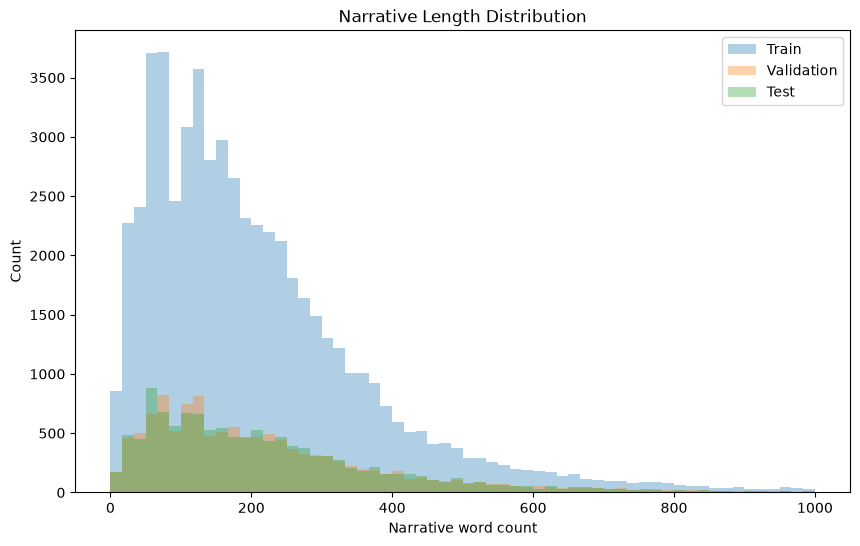

In [18]:
## Narrative Length Distibutions
plt.figure(figsize=(10, 6))

for data, label in [
    (train, "Train"),
    (val, "Validation"),
    (test, "Test")
]:
    plt.hist(
        data["narrative_word_count"],
        bins=60,
        range=(0, 1000),
        alpha=0.35,
        label=label
    )

plt.xlabel("Narrative word count")
plt.ylabel("Count")
plt.title("Narrative Length Distribution")
plt.legend()
plt.show()

##### Part 6 — Missingness Drift

Missingness is not automatically a data-quality problem.

Sometimes missingness itself carries information.

But if missingness patterns change across time, a model can experience
distribution shift even when the underlying categories look similar.

We inspect the columns that are potentially available at prediction time.

Important:

Post-intake fields are not treated as model features simply because
they have useful information.

In [19]:
candidate_columns = [
    "Product",
    "Sub-product",
    "Issue",
    "Sub-issue",
    "Consumer complaint narrative",
    "Company",
    "State",
    "ZIP code",
    "Tags"
]

missingness_rows = []

for col in candidate_columns:
    missingness_rows.append({
        "column": col,
        "train_missing_%": train[col].isna().mean() * 100,
        "val_missing_%": val[col].isna().mean() * 100,
        "test_missing_%": test[col].isna().mean() * 100
    })

missingness_drift = pd.DataFrame(missingness_rows)

display(missingness_drift.round(3))

,column,train_missing_%,val_missing_%,test_missing_%
0,Product,0.000,0.000,0.000
1,Sub-product,0.000,0.000,0.000
2,Issue,0.000,0.000,0.000
3,Sub-issue,12.604,11.895,11.991
4,Consumer complaint narrative,0.000,0.000,0.000
5,Company,0.000,0.000,0.000
6,State,0.779,0.594,0.675
7,ZIP code,0.361,0.553,0.610
8,Tags,84.858,84.346,82.868


##### Part 7 — Temporal Process Drift

The strongest evidence from Notebook 03 was that latency changed substantially over time.

Now we examine the process at a finer temporal resolution.

We calculate:

- Monthly volume
- Monthly median latency
- Monthly mean latency
- P95 latency
- Long-delay prevalence

The goal is to distinguish:-  stable process + random noise

from:-  changing operational process

In [22]:
## Add Month
for data in [train, val, test]:
    data["received_month"] = data["Date received"].dt.tz_localize(None).dt.to_period("M").astype(str)

In [25]:
monthly = (
    df_sorted
    .assign(received_month=df_sorted["Date received"].dt.tz_localize(None).dt.to_period("M").astype(str))
    .groupby("received_month")["triage_delay_days"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        p90=lambda x: x.quantile(.90),
        p95=lambda x: x.quantile(.95),
        p99=lambda x: x.quantile(.99)
    )
    .reset_index()
)

monthly[">7d_%"] = (
    df_sorted
    .assign(
        received_month=df_sorted["Date received"].dt.tz_localize(None).dt.to_period("M").astype(str),
        delayed=df_sorted["triage_delay_days"] > 7
    )
    .groupby("received_month")["delayed"]
    .mean()
    .values * 100
)

display(monthly.round(4))

,received_month,count,mean,median,p90,p95,p99,>7d_%
0,2026-03,21630,2.4186,0.0094,0.0581,21.6716,38.8591,7.8363
1,2026-04,21048,1.6655,0.0101,0.0374,6.9145,43.7338,4.9981
2,2026-05,17385,2.5239,0.0102,0.0542,22.9469,49.9543,7.9839
3,2026-06,16721,0.6859,0.0100,0.0347,0.0848,21.0828,3.2295
4,2026-07,5161,0.0490,0.0101,0.0334,0.0549,0.4832,0.1356
5,2026-08,1,0.0031,0.0031,0.0031,0.0031,0.0031,0.0000


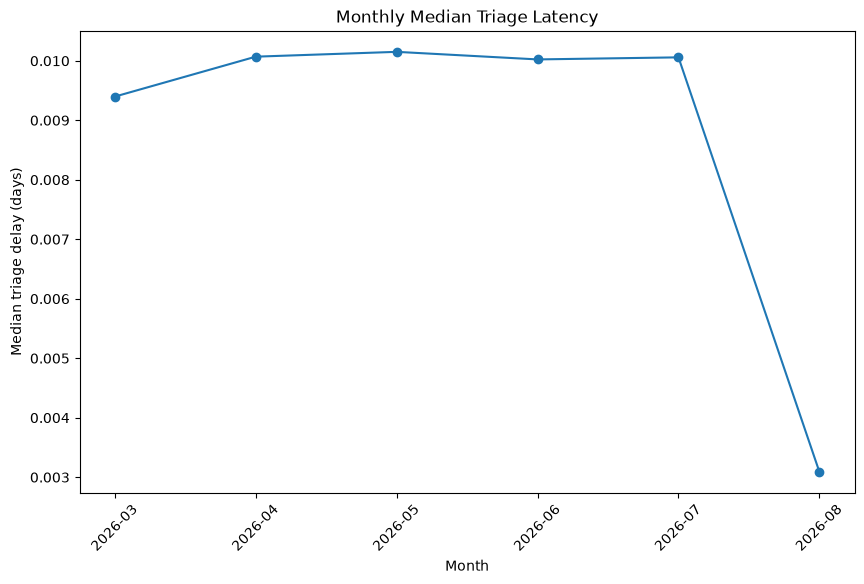

In [26]:
## Monthly Median
plt.figure(figsize=(10, 6))

plt.plot(
    monthly["received_month"],
    monthly["median"],
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Median triage delay (days)")
plt.title("Monthly Median Triage Latency")
plt.xticks(rotation=45)
plt.show()

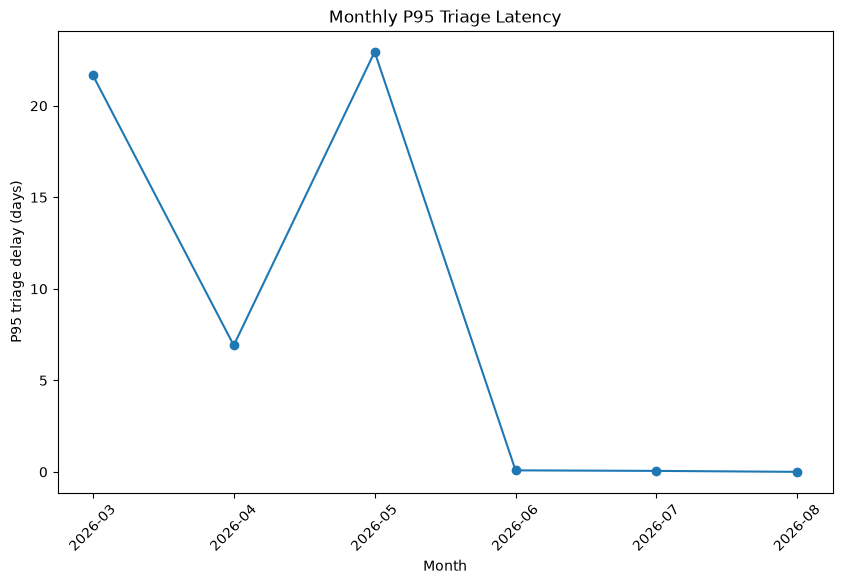

In [27]:
## Monthly P95
plt.figure(figsize=(10, 6))

plt.plot(
    monthly["received_month"],
    monthly["p95"],
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("P95 triage delay (days)")
plt.title("Monthly P95 Triage Latency")
plt.xticks(rotation=45)
plt.show()

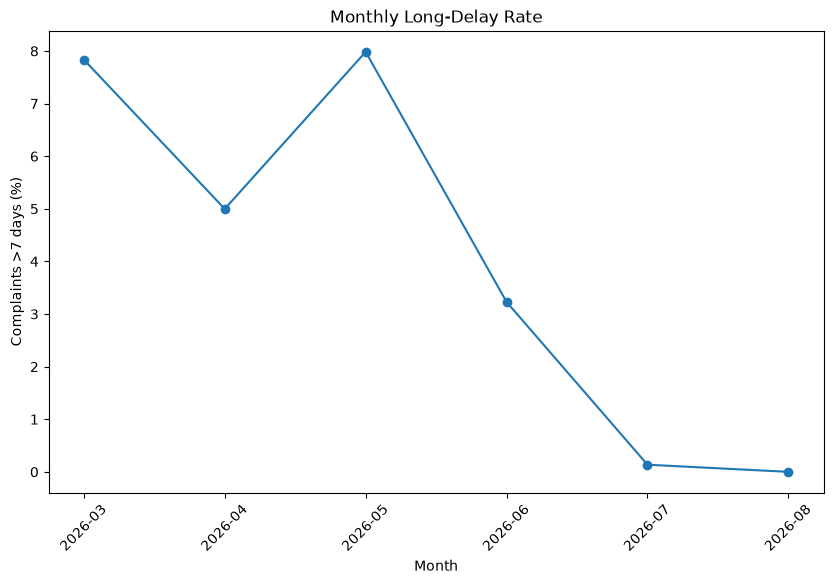

In [28]:
## Log-Delay Rate
plt.figure(figsize=(10, 6))

plt.plot(
    monthly["received_month"],
    monthly[">7d_%"],
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Complaints >7 days (%)")
plt.title("Monthly Long-Delay Rate")
plt.xticks(rotation=45)
plt.show()

##### Part 8 — Day-of-Week Stability

Notebook 05 showed Saturday had substantially higher latency.

But this could be caused by:

- Small sample size
- Concentration of long-delay cases
- Company mix
- Operational scheduling
- Genuine weekday/weekend process differences

We therefore inspect the full dataset descriptively.

> No causal interpretation is made from this table alone.

In [29]:
df_sorted["received_day"] = df_sorted["Date received"].dt.day_name()

weekday_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

weekday_summary = (
    df_sorted
    .groupby("received_day")["triage_delay_days"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        p95=lambda x: x.quantile(.95)
    )
    .reindex(weekday_order)
)

weekday_summary[">7d_%"] = (
    df_sorted.assign(delayed=df_sorted["triage_delay_days"] > 7)
    .groupby("received_day")["delayed"]
    .mean()
    .reindex(weekday_order) * 100
)

display(weekday_summary.round(4))

,count,mean,median,p95,>7d_%
received_day,,,,,
Monday,15687,1.5163,0.0099,8.1630,5.1316
Tuesday,17646,1.4713,0.0096,6.9484,4.9870
Wednesday,17725,1.4257,0.0097,5.7694,4.7673
Thursday,15786,1.3689,0.0096,4.7954,4.2949
Friday,6747,3.0807,0.0107,27.4960,9.6784
Saturday,1895,7.6485,0.0151,42.2072,24.6438
Sunday,6460,1.7124,0.0107,10.7292,5.4799


##### Part 9 — Delayed-Regime Robustness

Notebook 05 demonstrated that the one-stage model fails primarily on long delays.

Now we ask:

> Is the delayed regime itself stable enough to justify a dedicated model?

We examine several candidate thresholds.

For each threshold we consider:

- Number of delayed observations
- Percentage delayed
- Temporal stability
- Whether enough examples exist in development data

> We are not selecting the final threshold yet.

In [30]:
regime_rows = []

for threshold in [1, 3, 7, 14, 30]:

    for name, data in [
        ("Train", train),
        ("Validation", val),
        ("Test", test)
    ]:
        y = data["triage_delay_days"]
        delayed = y > threshold

        regime_rows.append({
            "threshold": threshold,
            "split": name,
            "delayed_n": delayed.sum(),
            "delayed_%": delayed.mean() * 100
        })

regime_stability = pd.DataFrame(regime_rows)

display(regime_stability.round(3))

,threshold,split,delayed_n,delayed_%
0,1,Train,4269,7.442
1,1,Validation,712,5.793
2,1,Test,249,2.026
3,3,Train,4169,7.268
4,3,Validation,699,5.687
5,3,Test,217,1.765
6,7,Train,3934,6.858
7,7,Validation,635,5.166
8,7,Test,113,0.919
9,14,Train,3316,5.781


##### Interpretation:

Around 1.0 → similar prevalence
Much below 1.0 → delayed regime became less common
Much above 1.0 → delayed regime became more common

In [31]:
## Train/Validation Prevalance Ratio
regime_pivot = regime_stability[
    regime_stability["split"].isin(["Train", "Validation"])
].pivot(
    index="threshold",
    columns="split",
    values="delayed_%"
)

regime_pivot["Validation / Train"] = (
    regime_pivot["Validation"] / regime_pivot["Train"]
)

display(regime_pivot.round(3))

split,Train,Validation,Validation / Train
threshold,,,
1,7.442,5.793,0.778
3,7.268,5.687,0.782
7,6.858,5.166,0.753
14,5.781,2.896,0.501
30,3.701,0.895,0.242


##### Part 10 — Does Latency Behave Like One Continuous Regime?

A crucial modeling question is whether:

    0.01 days
    0.05 days
    0.5 days
    5 days
    20 days

behave like points on one smooth continuum.

Notebook 05 suggested otherwise.

The model:

- predicts too much for immediate cases
- predicts too little for long-delay cases

This looks more like a mixture of operational regimes.

> We therefore inspect target quantiles and regime separation.

In [32]:
regime_bins = [-np.inf, 0.01, 0.05, 1, 7, 30, np.inf]
regime_labels = [
    "<=0.01d",
    "0.01-0.05d",
    "0.05-1d",
    "1-7d",
    "7-30d",
    ">30d"
]

df_sorted["delay_regime"] = pd.cut(
    df_sorted["triage_delay_days"],
    bins=regime_bins,
    labels=regime_labels
)

regime_summary = (
    df_sorted
    .groupby("delay_regime", observed=False)["triage_delay_days"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        p90=lambda x: x.quantile(.90)
    )
)

regime_summary["percentage"] = (
    regime_summary["count"] / len(df_sorted) * 100
)

display(regime_summary.round(4))

,count,mean,median,p90,percentage
delay_regime,,,,,
<=0.01d,41340,0.0052,0.0052,0.0089,50.4479
0.01-0.05d,33559,0.0196,0.0170,0.0327,40.9526
0.05-1d,1817,0.1405,0.0670,0.3887,2.2173
1-7d,548,4.4702,4.6815,6.7490,0.6687
7-30d,2444,16.7663,15.4516,26.9950,2.9825
>30d,2238,43.9747,40.3312,51.8334,2.7311


##### Drift Score: PSI
##### Part 11 — Population Stability Index (PSI)

PSI provides a compact way to quantify distribution change.

Conceptually:

    PSI ≈ difference between reference distribution
           and comparison distribution

We use Train as the reference.

PSI is used here as a diagnostic indicator, not as an absolute truth.

Typical rough interpretation:

< 0.10   → small change
0.10–0.25 → moderate change
> 0.25   → substantial change

> These thresholds are heuristics, not laws of nature.

In [33]:
## PSI Helper
def calculate_psi(reference, comparison, bins=10):
    reference = np.asarray(reference, dtype=float)
    comparison = np.asarray(comparison, dtype=float)

    reference = reference[np.isfinite(reference)]
    comparison = comparison[np.isfinite(comparison)]

    quantiles = np.linspace(0, 1, bins + 1)
    edges = np.quantile(reference, quantiles)
    edges = np.unique(edges)

    if len(edges) < 3:
        return np.nan

    edges[0] = -np.inf
    edges[-1] = np.inf

    ref_counts, _ = np.histogram(reference, bins=edges)
    cmp_counts, _ = np.histogram(comparison, bins=edges)

    ref_pct = ref_counts / len(reference)
    cmp_pct = cmp_counts / len(comparison)

    epsilon = 1e-6

    ref_pct = np.clip(ref_pct, epsilon, None)
    cmp_pct = np.clip(cmp_pct, epsilon, None)

    psi = np.sum(
        (cmp_pct - ref_pct) *
        np.log(cmp_pct / ref_pct)
    )

    return psi

In [34]:
## Target PSI
target_psi = pd.DataFrame({
    "comparison": ["Validation vs Train", "Test vs Train"],
    "PSI": [
        calculate_psi(
            train["triage_delay_days"],
            val["triage_delay_days"]
        ),
        calculate_psi(
            train["triage_delay_days"],
            test["triage_delay_days"]
        )
    ]
})

display(target_psi.round(4))

,comparison,PSI
0,Validation vs Train,0.0049
1,Test vs Train,0.0286


##### PSI Interpretation Warning

The target is extremely skewed and contains rare extreme values.

Therefore PSI should NOT replace:

- Quantiles
- Threshold prevalence
- Temporal plots
- Business interpretation

> PSI is only a compact supporting diagnostic.

##### Development Conclusion Matrix
##### Part 12 — Robustness Diagnosis

We now bring the evidence together.

The important distinction is:

##### A. Model limitation

Evidence:

- Regression compresses predictions
- Immediate regime is overpredicted
- Long-delay regime is underpredicted
- >7d recall is very low

##### B. Process drift

Evidence:

- Target mean/P95/P99 change over time
- Long-delay prevalence changes
- Product composition changes
- Company coverage changes

##### C. Regime structure

Evidence:

- Huge immediate-delay population
- Small but operationally important delayed population
- One-stage model struggles with both simultaneously

The final question:

> Is a two-stage/hurdle architecture justified?

In [35]:
## Automated Compact Summary
summary = {
    "Train mean delay": train["triage_delay_days"].mean(),
    "Validation mean delay": val["triage_delay_days"].mean(),
    "Test mean delay": test["triage_delay_days"].mean(),

    "Train P95": train["triage_delay_days"].quantile(.95),
    "Validation P95": val["triage_delay_days"].quantile(.95),
    "Test P95": test["triage_delay_days"].quantile(.95),

    "Train >7d %": (train["triage_delay_days"] > 7).mean() * 100,
    "Validation >7d %": (val["triage_delay_days"] > 7).mean() * 100,
    "Test >7d %": (test["triage_delay_days"] > 7).mean() * 100,

    "Validation target PSI": target_psi.loc[
        target_psi["comparison"] == "Validation vs Train", "PSI"
    ].iloc[0],

    "Test target PSI": target_psi.loc[
        target_psi["comparison"] == "Test vs Train", "PSI"
    ].iloc[0],
}

for key, value in summary.items():
    print(f"{key}: {value:.4f}")

Train mean delay: 2.2181
Validation mean delay: 1.0983
Test mean delay: 0.1819
Train P95: 18.8653
Validation P95: 7.4209
Test P95: 0.0551
Train >7d %: 6.8582
Validation >7d %: 5.1664
Test >7d %: 0.9192
Validation target PSI: 0.0049
Test target PSI: 0.0286


##### Final Analysis Insights

This cell is not just a conclusion paragraph. Instead convert statistical observations into modeling decisions.

##### Analysis Insights

##### 1. Target Stability

The triage-delay target is not temporally stationary.

The temporal splits show meaningful changes in:

- Mean latency
- Upper-tail latency
- Long-delay prevalence

Therefore, temporal drift must be considered during model development and evaluation.

---

##### 2. Process Regime Structure

The target contains a dominant near-immediate regime and a much smaller delayed regime.

The majority of complaints are processed within minutes, while a small proportion experience delays of several days or more.

This creates an asymmetric learning problem:

- The immediate regime dominates sample count.
- The delayed regime dominates operational risk.

Therefore, minimizing average error across all observations can encourage the model to favor the dominant immediate regime.

---

##### 3. One-Stage Regression Limitation

Notebook 05 showed that the one-stage regression model:

- overpredicts immediate cases
- underpredicts long-delay cases
- compresses predictions toward the center
- has very poor recall for >7-day delays

Therefore, simply increasing model complexity is unlikely to address the fundamental problem.

The failure appears structural rather than merely algorithmic.

---

##### 4. Population Drift

Product, Company, State, and narrative distributions should be compared across temporal splits.

Any meaningful changes indicate that the validation/test populations are not identical to the training population.

This means performance must be interpreted together with population composition.

---

##### 5. Company Generalization

Company has potentially useful operational signal but also high-cardinality memorization risk.

Performance should eventually be separated into:

- Known companies
- Previously unseen companies

A strong model on known companies alone is insufficient evidence of robust generalization.

---

##### 6. Test-Period Caution

The test period contains substantially fewer long-delay observations than the training period.

Therefore:

> A strong final test score would not automatically prove that the model learned the long-delay regime.

The frozen test set must remain untouched for model selection.

---

##### 7. Modeling Decision

The evidence supports investigating a two-stage architecture:

Stage 1:
    Predict whether a complaint enters a delayed regime.

Stage 2:
    Conditional on being delayed, predict the duration.

Conceptually:

Complaint received
        ↓
Delayed?
   ┌────┴────┐
   No        Yes
   ↓          ↓
near-zero   duration model
delay       ↓
            predicted delay

This architecture directly reflects the operational structure discovered during EDA and residual analysis.

---

##### 8. Threshold Decision

The final delayed threshold should NOT be selected merely because >7 days sounds intuitive.

Candidate thresholds should be evaluated using:

- Business meaning
- Sufficient sample size
- Train/validation stability
- Learnability
- Operational usefulness
- Expected decision/action

Candidate thresholds:

>1d
>3d
>7d
>14d
>30d

Notebook 07 will formally compare these candidates.

---

##### 9. Feature Governance Reminder

Product, Sub-product, Issue, Sub-issue, and Tags remain conditional features.

Their use requires confirmation that the values are genuinely available at the prediction timestamp.

Post-intake fields remain prohibited:

- Date sent to company
- Company public response
- Company response to consumer
- Timely response?

Complaint ID remains an identifier rather than a predictive feature.

---

##### Final Conclusion

The current evidence indicates that the triage-latency problem is better represented as:

    Immediate processing regime
                +
    Rare delayed operational regime

rather than as a single homogeneous regression problem.

> Therefore, the next development stage should investigate a two-stage/hurdle formulation rather than simply continuing to optimize the existing one-stage Ridge regression.

##### Decision Gate — Proceed to Notebook 07?

Proceed only if the analysis supports the following:

##### ✓ Target is structurally valid
Yes — established in Notebook 01.

##### ✓ Temporal split is necessary
Yes — established in Notebook 03.

##### ✓ One-stage regression has meaningful failure modes
Yes — established in Notebook 05.

##### ✓ Long-delay regime exists
Yes.

##### ✓ Long-delay regime is operationally meaningful
To be validated using business context.

##### ✓ Candidate delayed thresholds have sufficient development data
Evaluate >1d, >3d, >7d, >14d, >30d.

##### ✓ Drift does not invalidate the entire modeling problem
If substantial drift exists, model robustness must explicitly account for it.

##### Decision

If these conditions hold:

→ Proceed to Notebook 07:
Delayed-Regime Target Design

> ##### What Notebook 06 should teach us as a Data Scientist: The deeper lesson here is bigger than this project.

- A beginner asks:- “Which model gives better MAE?”

- A stronger practitioner asks:-  “Why is the model making these errors?”

- An expert asks:-  “Is the thing I'm trying to predict actually one homogeneous phenomenon?”

- And the strongest question is:-  “What is the structure of the real-world process generating this target?”

> For Current CFPB problem, the evidence is increasingly pointing toward:
                REAL OPERATIONAL PROCESS
                         │
                         ▼
                 Complaint Received
                         │
              ┌──────────┴──────────┐
              │                     │
        Normal workflow        Operational issue
              │                     │
              ▼                     ▼
       minutes / hours         days / weeks
              │                     │
              └──────────┬──────────┘
                         ▼
                  Observed latency

> That is why the two-stage architecture isn't merely a modeling trick.

  - It is an attempt to make the ML architecture reflect the structure of the business process.                  